For time-series observations, high-energy particles called "cosmic rays" can contaminate your data in complicated ways. They deposit a significant amount of energy into random locations in every exposure. While cosmic rays can be mitigated during flux extraction, those techniques can fail when cosmic ray contamination is too significant (or happens to fall on an unfortunate set of pixels).

In this section, we show how ```specsuite``` can flag, verify, and remove cosmic ray contamination.

In [1]:
import specsuite as ss

# Only need a bias to correct science exposures
bias = ss.average_matching_files(
    path = "../data/KOSMOS/calibrations",
    tag = "bias",
    crop_bds = (400, 700),
)

# Only made up of five images
science = ss.collect_images_array(
    path = "../data/KOSMOS/target",
    tag = "toi3884",
    crop_bds = (400, 700),
) - bias

## Basic Usage
### _Locating Cosmic Rays_
Cosmic rays are extremely random. They will appear in a single exposure and will fall at a random location along the detector. In Fourier space, these cosmic will show up as high-frequency features in all three dimensions. To isolate cosmic rays, we can mask out low-frequency contributions to dampen features that are relatively invariant over a small series of exposures. The mask we apply is given by...

\begin{equation*}
f(\vec{\omega}) = \frac{(2\pi)^{-3/2}}{\sigma_x\sigma_y\sigma_t} \cdot \exp\left[-\frac{1}{2} \left( \frac{\omega_x^2}{\sigma_x^2}  + \frac{\omega_y^2}{\sigma_y^2} + \frac{\omega_z^2}{\sigma_z^2} \right)\right]
\end{equation*}

where $\omega$ is the frequency in Fourier space and $\sigma_i$ is the standard deviation along that particular axis. While there are a couple of adjustable knobs here, the simplest version of the process just requires a series of exposures...

In [2]:
# Attempts to identify outliers in time-series data
locations, scrubbed_images = ss.flag_cosmic_rays(
    images = science,
)

The first return, ```locations```, is a dictionary containing potential cosmic rays for every image. Each key represents the index of the image, and the values are (x, y) points representing the approximate location of the cosmic ray. For example, here are the all detected cosmic rays from the first exposure...

In [3]:
# Prints the header
print("Potential Cosmic Ray Locations:")
print("-------------------------------")

# Iterates over all detected points in the first exposure
for x,y in locations[0]:
    print(f" - ({x}, {y})")

Potential Cosmic Ray Locations:
-------------------------------
 - (464, 11)
 - (875, 30)
 - (599, 31)
 - (1253, 32)
 - (1777, 82)
 - (1539, 91)
 - (635, 212)
 - (595, 213)
 - (1174, 221)
 - (623, 292)


The second return, ```scrubbed_images```, shows each image where a 3D Gaussian mask has been applied to mask out low frequencies in the FFT. For reference, let's look at the original + scrubbed image for the first exposure...

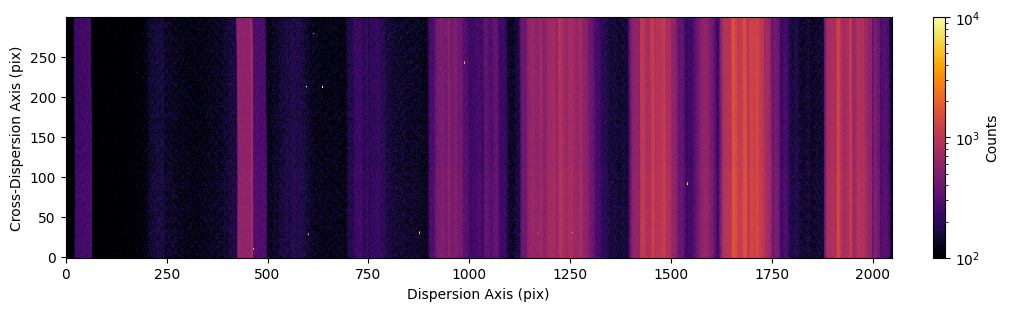

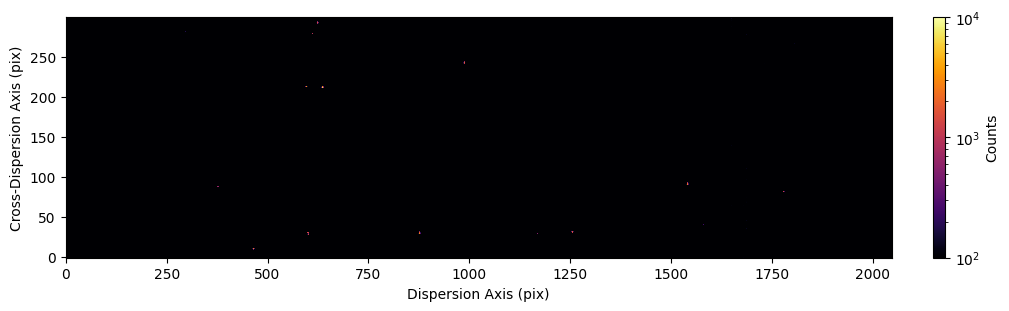

In [4]:
# Original Exposure
ss.plot_image(
    science[0],
    norm='log',
    vmin=1e2,
    vmax=1e4,
)

# 'Scrubbed' Exposure
ss.plot_image(
    scrubbed_images[0],
    norm='log',
    vmin=1e2,
    vmax=1e4,
)

The above process is far from perfect, but it gives us a good initial guess for where cosmic rays are in each exposure.

### _Verify Cosmic Rays_
We can use the following function to verify how much of an outlier each "detected ray" is. This looks at surrounding exposures, calculates the mean-averaged deviation (MAD) of each pixel, then determines how many MADs each pixel lies above the median exposure...

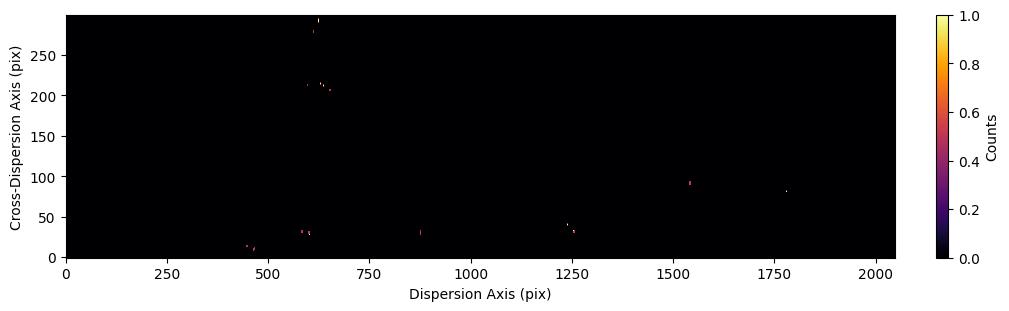

In [5]:
# Identifies pixels with a MAD-normalized residual above 100
masks, verified_cosmic_rays = ss.verify_cosmic_rays(
    images = science,
    locs = locations,
    thresh = 100,
)

# Plots the cosmic ray mask for the first exposure
ss.plot_image(masks[0])

By default, the mask for "verified cosmic rays" has a value of 1.0 for contaminated pixels and 0.0 otherwise. If ```ray_padding``` is greater than zero (defaults to 1.0), then surrounding pixels will have a non-zero value as well.

If you wanted to see the generate masks for each pixel, you can find them in the ```verified_cosmic_rays``` dictionary! The key represents the image index, and each entry contains the [(x, y), mask] of each verified cosmic ray in the image. Let's take a look at the first three cosmic rays detected in the first image...

Potential Cosmic Ray Locations:
-------------------------------
 - (464, 11)


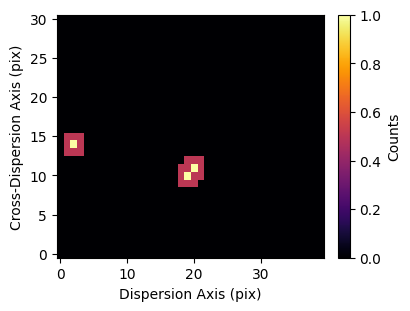

 - (875, 30)


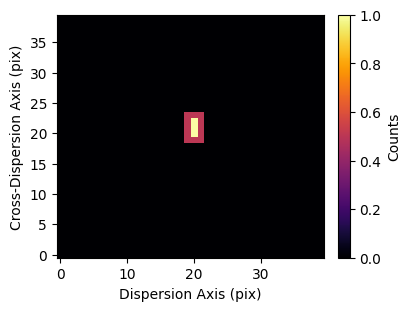

 - (599, 31)


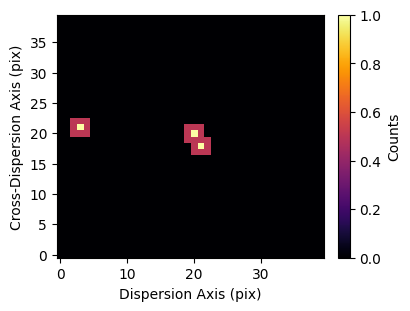

In [6]:
# Prints the header
print("Potential Cosmic Ray Locations:")
print("-------------------------------")

# Iterates over the first three masks in the first exposure
for loc, mask in verified_cosmic_rays[0][:3]:
    print(f" - ({loc[0]}, {loc[1]})")
    ss.plot_image(mask, figsize=(4, 3))

### _Remove Cosmic Rays_
In general, you should not remove cosmic rays in the way we are about to. Instead, you should use your cosmic ray mask to inform another part of your reduction (such as using it as a mask during flux extraction). The following function replaces contaminated pixels with the median of several surrounding exposures...

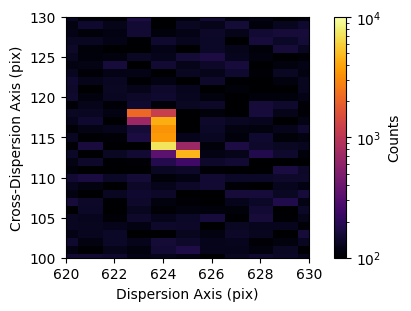

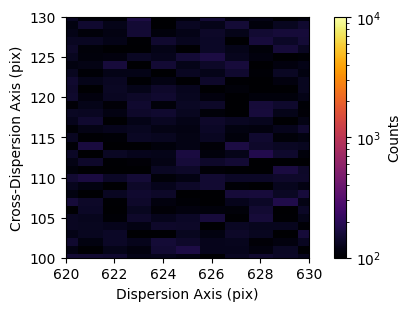

In [7]:
# Replaces flagged cosmic rays with surrounding median
cleaned_science = ss.replace_cosmic_rays(
    images = science,
    masks = masks,
)

# Arguments defined here for readability
KWARGS = {
    "vmin": 1e2,
    "vmax": 1e4,
    "norm": "log",
    "xlim": (620, 630),
    "ylim": (100, 130),
    "figsize": (4, 3)
}

# Plots before vs. after cleaning
ss.plot_image(science[2], **KWARGS)
ss.plot_image(cleaned_science[2], **KWARGS)

We can clearly see the cosmic ray disappear! The statistical implications of this process are thorny, though, and it should only be done when no other alternatives are available.

## Common Errors
### _Flagging Too Many / Few Pixels_
If the Gaussian mask is ill-suited for your data or the threshold is incorrect, cosmic rays may not be flagged properly. As a first step, look at the plot generated using the ```debug``` argument...

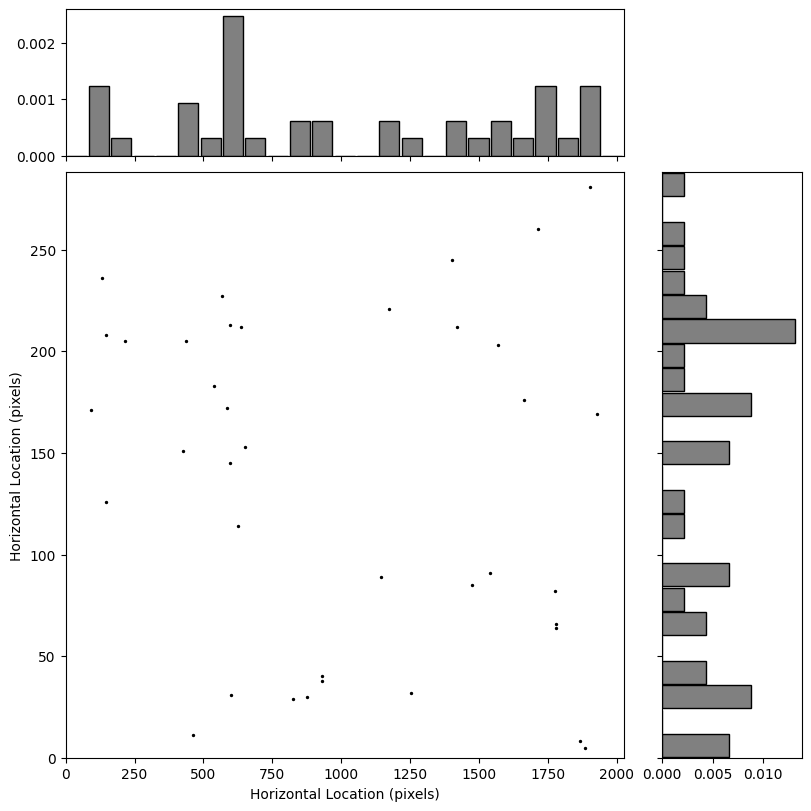

In [8]:
# Shows how 'debug' plot should look
locations, scrubbed_images = ss.flag_cosmic_rays(
    images = science,
    debug = True,
)

This is a small dataset, so it's a little hard to determine how randomly-sampled these detections are. Ideally, the distribution is relatively flat. To demonstrate one point of failure, let's look at how setting the threshold too low impacts cosmic ray detection...

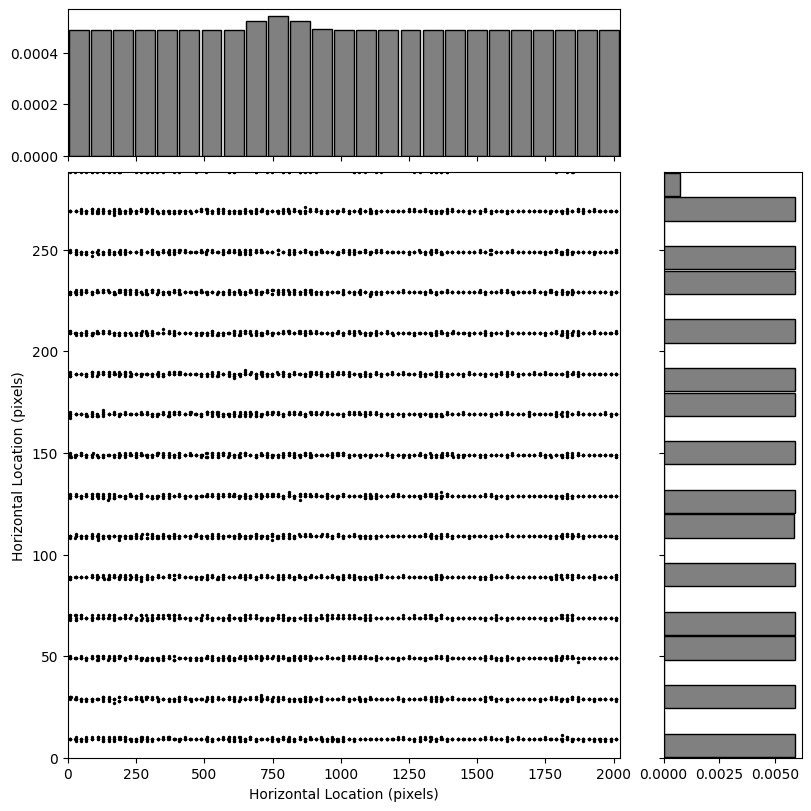

In [9]:
# Flagging too many pixels
_, scrubbed_images = ss.flag_cosmic_rays(
    images = science,
    thresh = 10,
    debug = True,
)

It's also possible for the Gaussian mask to have too small / large of a standard deviation. Let's look at how this impacts our flagging routine...

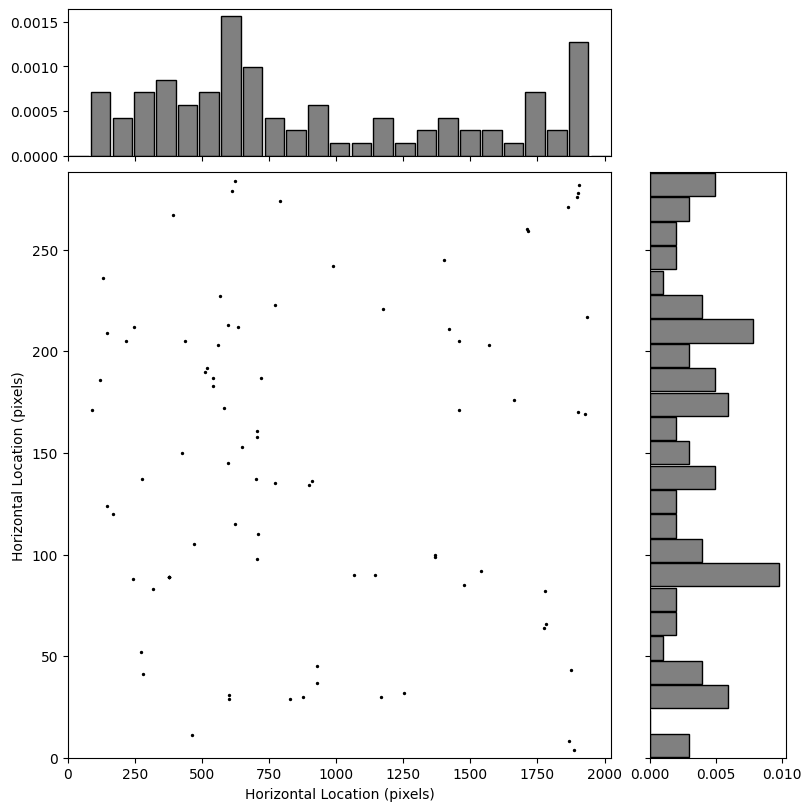

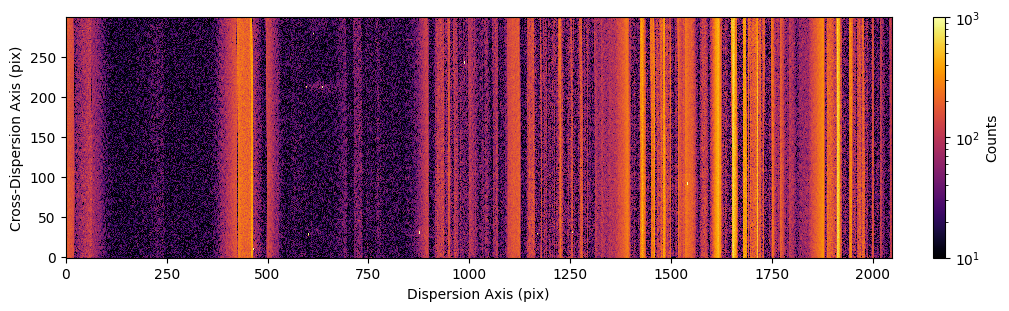

In [10]:
# Intentionally uses a bad Gaussian mask
_, scrubbed_images = ss.flag_cosmic_rays(
    images = science,
    gauss_stds = (10, 10, 10),
    debug = True,
)

# Shows the 'bad' scrubbed image
ss.plot_image(
    scrubbed_images[0],
    norm='log',
    vmin=1e1,
    vmax=1e3,
)

We can see that the time-persistent background features were not entirely masked out, which resulted in several false positives. If you are having either of these issues, try modifying the ```gauss_stds``` and ```thresh``` arguments until the scrubbed image and debug plots look reasonable.

### _Bad Verification Threshold_
You are likely to run into issues with ```verify_cosmic_rays()``` if you choose a bad threshold. This theshold determines how many MADs away from the median a pixel needs to be before being flagged as an outlier. Let's reduce our ```locations``` dictionary to single entry and look at the debugging plot...

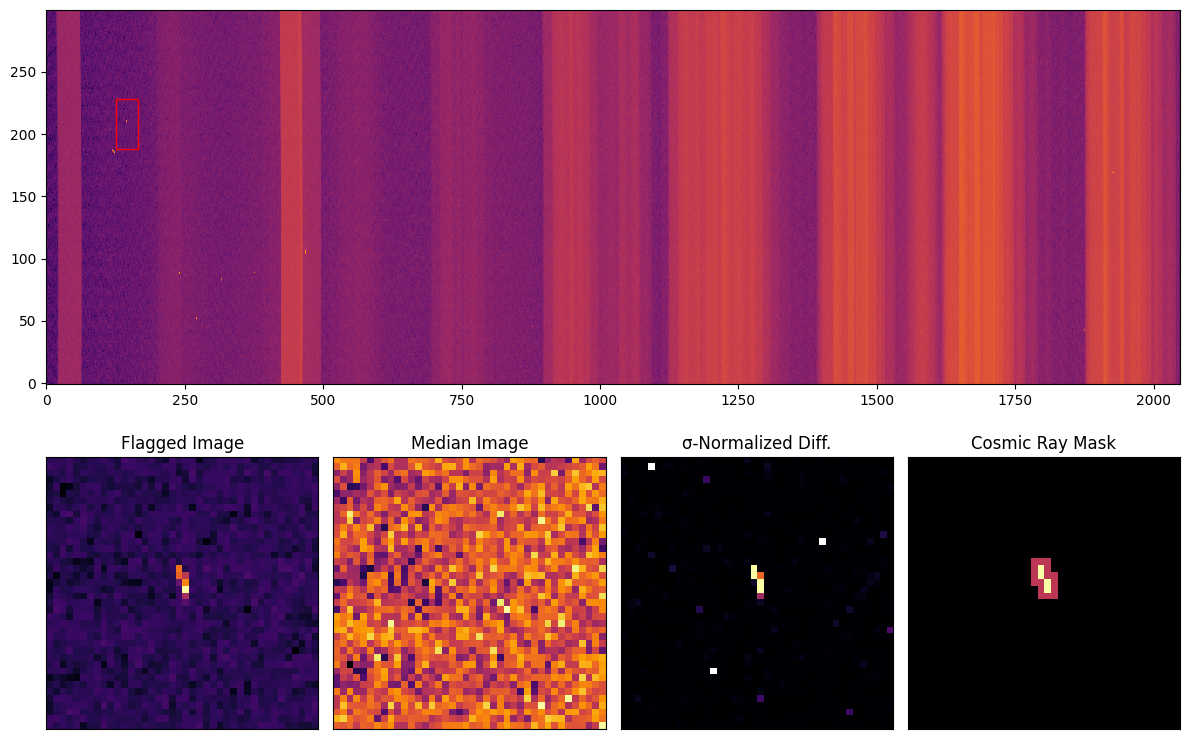

In [11]:
import numpy as np

# Defines new dictionary to simplify 'debug' plot
single_cosmic_ray = {
    0: np.array([]),
    1: np.array([locations[1][3]]),
    2: np.array([]),
    3: np.array([]),
    4: np.array([]),
}

# Plots the `debug` plot for a single cosmic ray
_, _ = ss.verify_cosmic_rays(
    images = science,
    locs = single_cosmic_ray,
    thresh = 100,
    debug = True,
)

We clearly see that the final "cosmic ray mask" captures the most significant contamination from the "flagged image" subplot. This is because the brightest pixels in the "sigma-normalized difference" are well-matched with the cosmic ray we are looking at. However, if we set the threshold too low, we get several false positives...

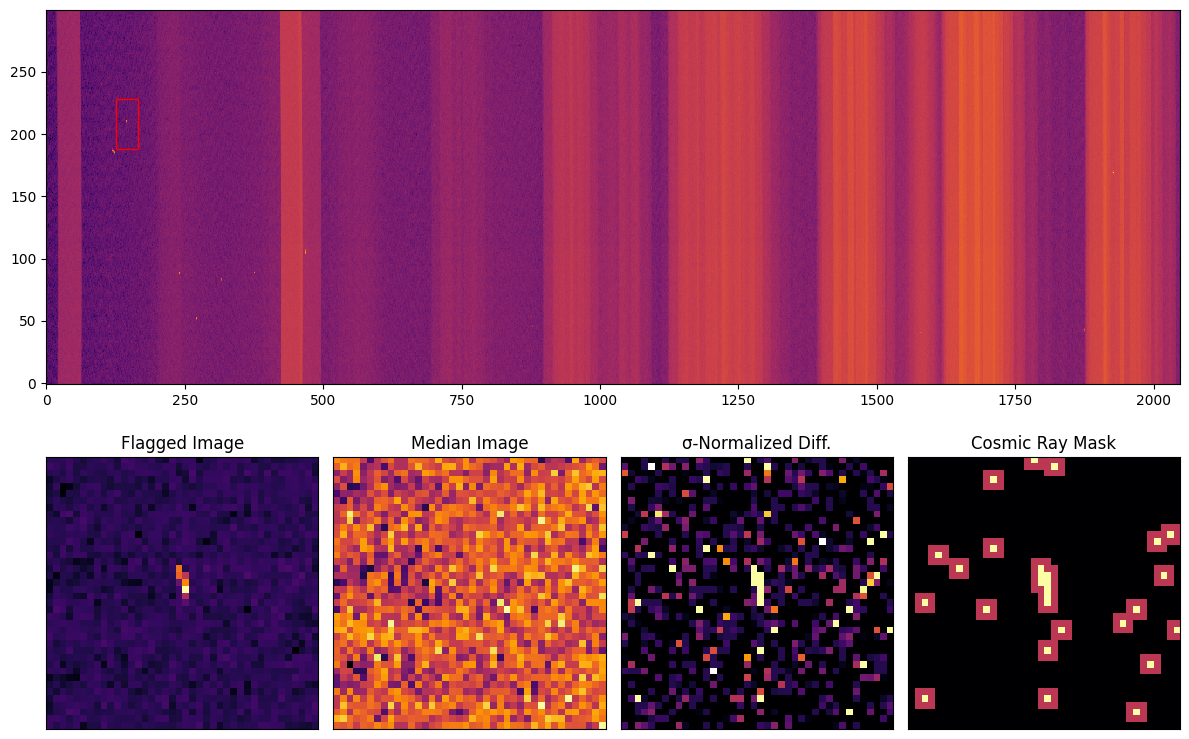

In [12]:
# Sets the theshold too low
_, _ = ss.verify_cosmic_rays(
    images = science,
    locs = single_cosmic_ray,
    thresh = 5,
    debug = True,
)

When the threshold is too low, we get the opposite issue...

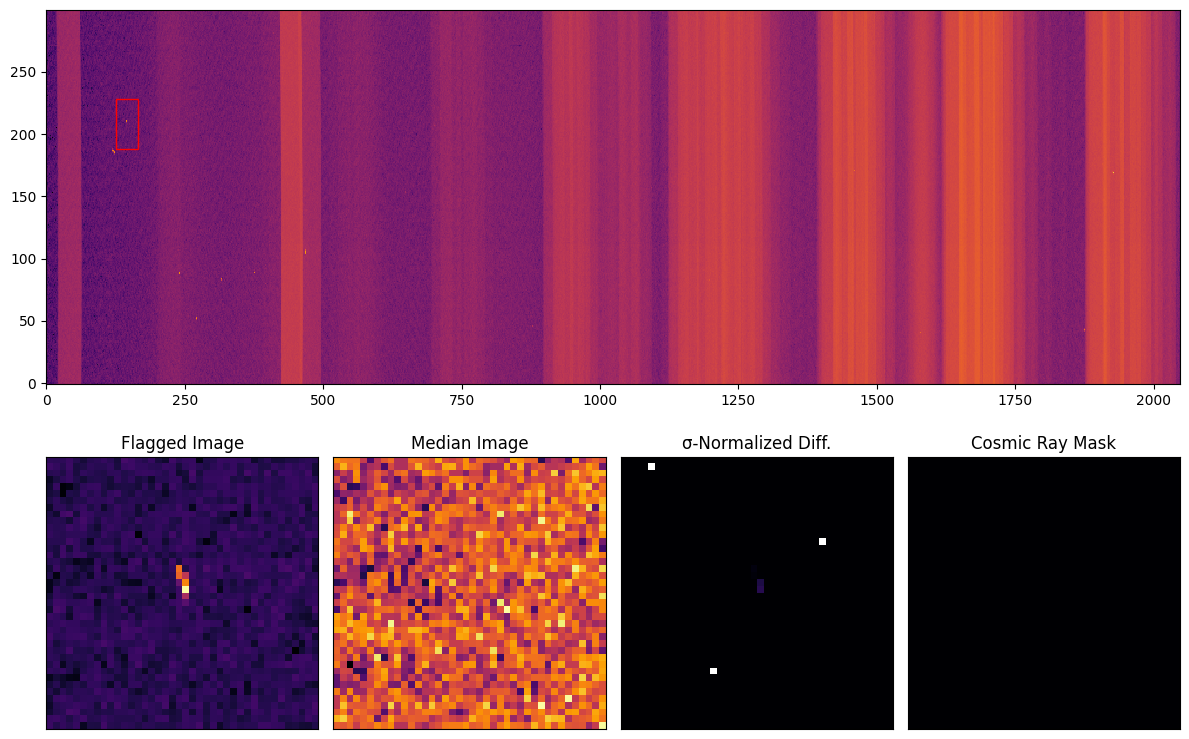

In [13]:
# Sets the threshold too high
_, _ = ss.verify_cosmic_rays(
    images = science,
    locs = single_cosmic_ray,
    thresh = 10000,
    debug = True,
)

If you notice that cosmic ray masks look incorrect, try verifying the threshold used for detecting outliers. Generally, lower threshold result in more detections and higher thresholds result in less.

### _Incorrectly Padding Masks_
As mentioned above, an optional argument allows you to flag pixels around "verified cosmic rays" as "potentially contaminated." These are assigned a value half of the last layer to help distinguish between them. By default, this value is set to 1, but you can increase or lower it to fit your needs. For example, you can raise it to five layers...

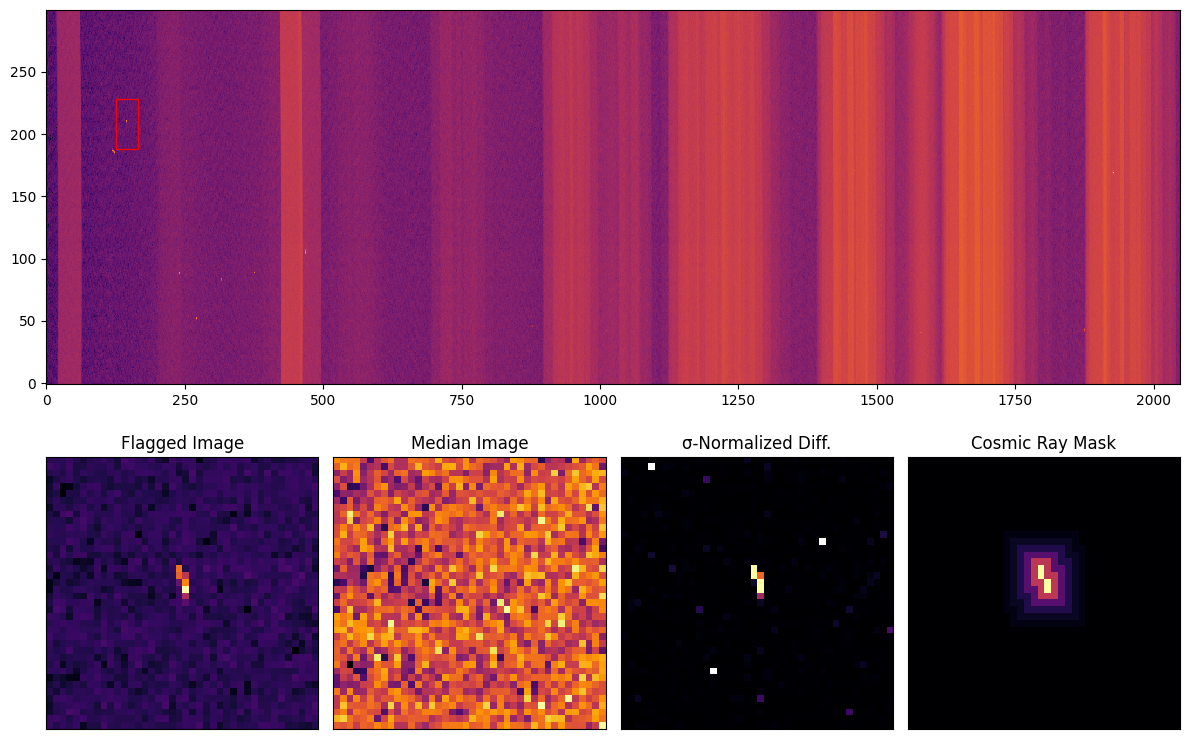

In [14]:
# Sets ray padding to '5'
_, _ = ss.verify_cosmic_rays(
    images = science,
    locs = single_cosmic_ray,
    thresh = 100,
    ray_padding = 5,
    debug = True,
)

We can see that the mask has a much "puffier" shape than it did before. Conversely, you can remove padding completely!

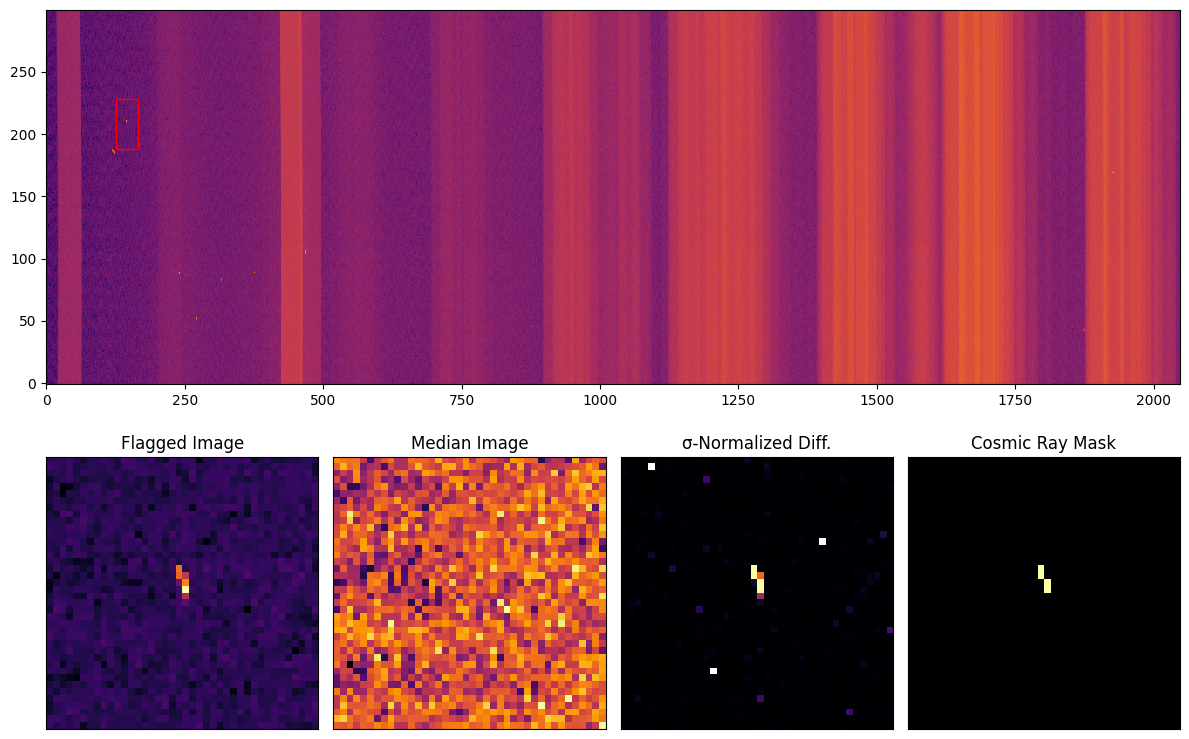

In [15]:
# Sets ray padding to '0'
_, _ = ss.verify_cosmic_rays(
    images = science,
    locs = single_cosmic_ray,
    thresh = 100,
    ray_padding = 0,
    debug = True,
)

```specsuite``` defaults to ```ray_padding=1``` since ```verify_cosmic_rays()``` has a habit of only catching the most contaminated pixels. An option that provides you some flexibility is to enable ray padding, but handle each layer afterwards. Here are two examples where the masks are modified after being generated...

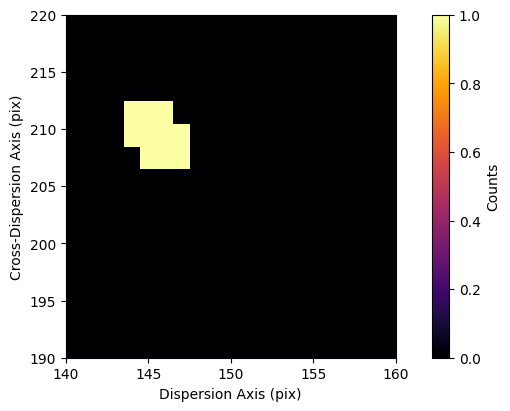

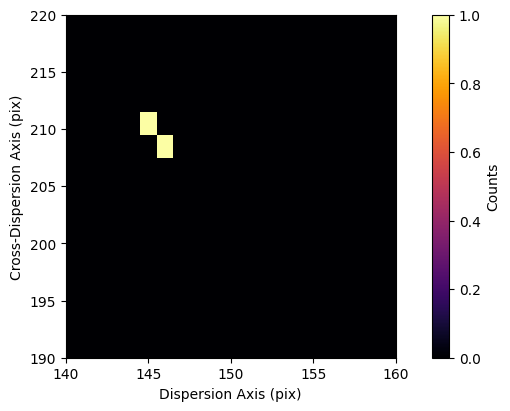

In [16]:
# Sets ray padding to '5'
mask, _ = ss.verify_cosmic_rays(
    images = science,
    locs = single_cosmic_ray,
    thresh = 100,
)

# All non-zero pixels should be masked
mask_option_1 = mask[1].copy()
mask_option_1[mask_option_1 > 0.0] = 1.0
ss.plot_image(
    mask_option_1,
    xlim=(140, 160),
    ylim=(190, 220),
    figsize=(5, 4),
)

# Only verified pixels should be masked
mask_option_2 = mask[1].copy()
mask_option_2[mask_option_2 < 1.0] = 0.0
ss.plot_image(
    mask_option_2,
    xlim=(140, 160),
    ylim=(190, 220),
    figsize=(5, 4),
)
